# Анализ Turbovec для RAG-поиска

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2/bw=4; два прогона: dim=[512, 1024])
2. Объединение всех прогонов в общую таблицу
3. Для каждой конфигурации (dim, bit_width) усреднить по-вопросные метрики и провизуализировать (line chart):
- Recall@1
- Recall@5
- Recall@10
- MRR
4. Бутстрап доверительных интервалов для парной разницы средних
5. McNemar тест (целевой контекст найден в топ-k)
6. Forest plot (главный график со сводной информацией)

In [15]:
# Утилиты
from pathlib import Path
import re
import json
RESULTS_DIR = str(Path.cwd().parent / "results/rag_search")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + "/"

In [16]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

## 1. Загрузка данных выборочно

In [17]:
tv_dim512_bw2 = pd.read_csv(RESULTS_DIR + 'turbovec_small_dim512_bw2_20260701_190915.csv')
bl_dim1024 = pd.read_csv(RESULTS_DIR + 'baseline_small_dim1024_20260701_231302.csv')

In [18]:
tv_dim512_bw2.head()

,question_id,question_text,target_context_id,time_ms,recall@1,recall@5,recall@10,mrr
0,question_1,Где встречаются первые упоминания о строении ч...,context_1,15.633583,0,0,0,0.0
1,question_2,Когда египетский врач Имхотеп впервые описал н...,context_1,0.000000,0,0,0,0.0
2,question_3,Как называется корректирующая оптическая систе...,context_2,0.000000,0,1,1,0.5
3,question_4,Какая теория была отвергнута после смерти Веге...,context_3,0.000000,1,1,1,1.0
4,question_5,Чему не уступают по красоте изделия из прессов...,context_4,0.000000,0,1,1,0.5


In [19]:
tv_dim512_bw2.describe()

,time_ms,recall@1,recall@5,recall@10,mrr
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.261463,0.212000,0.340500,0.398000,0.267613
std,1.913690,0.408827,0.473996,0.489608,0.401636
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,1.000000,0.500000
max,16.216993,1.000000,1.000000,1.000000,1.000000


## 2. Группировка таблиц

In [20]:
frames = []

for file in Path(RESULTS_DIR).glob("*.csv"):
    name = file.stem

    if name.startswith("baseline"):
        method = "baseline"
        bit_width = np.nan
    else:
        method = "turbovec"
        bit_width = int(re.search(r"bw(\d+)", name).group(1))

    dim = int(re.search(r"dim(\d+)", name).group(1))

    run_id = name.split("_")[-2] + "_" + name.split("_")[-1]

    df = pd.read_csv(file)

    df["method"] = method
    df["bit_width"] = bit_width
    df["dim"] = dim
    df["run_id"] = run_id

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

all_df["variant"] = np.where(
    all_df.method=="baseline",
    "baseline",
    "turbovec_bw"+all_df.bit_width.astype("Int64").astype(str)
)

In [21]:
all_df.tail()

,question_id,question_text,target_context_id,time_ms,recall@1,recall@5,recall@10,mrr,method,bit_width,dim,run_id,variant
11995,question_1996,В каком году была опубликована биография Пьера...,context_1407,0.0,0,0,0,0.000,turbovec,4.0,512,20260701_190915,turbovec_bw4
11996,question_1997,Когда тейлоризм устарел?,context_1408,0.0,0,0,0,0.000,turbovec,4.0,512,20260701_190915,turbovec_bw4
11997,question_1998,Где не может жить окунь?,context_1409,0.0,0,1,1,0.200,turbovec,4.0,512,20260701_190915,turbovec_bw4
11998,question_1999,Что заставляло первобытных людей бороться?,context_1410,0.0,0,0,1,0.125,turbovec,4.0,512,20260701_190915,turbovec_bw4
11999,question_2000,Как определяется роль водорода в природе?,context_1411,0.0,0,0,0,0.000,turbovec,4.0,512,20260701_190915,turbovec_bw4


## 3. Вычисление метрик

In [22]:
summaries = {}
for f in sorted(Path(RESULTS_DIR).glob("summary_*.json")):
    s = json.loads(f.read_text())
    summaries[s["run_id"]] = s

MAIN_METRICS = ["recall@1", "recall@5", "recall@10", "mrr"]

def compute_metrics(sub):
    run_id = sub["run_id"].iloc[0]
    bit_width = sub["bit_width"].iloc[0]
    return (run_id, bit_width) + tuple(sub[m].mean() for m in MAIN_METRICS)

metrics_df = pd.DataFrame(
    [compute_metrics(sub) + (variant, summaries[run_id]["dim"])
     for (run_id, variant), sub in all_df.groupby(["run_id", "variant"])],
    columns=["run_id", "bit_width"] + MAIN_METRICS + ["variant", "dim"],
)
metrics_df.round(4)

,run_id,bit_width,recall@1,recall@5,recall@10,mrr,variant,dim
0,20260701_190915,NaN,0.2035,0.3215,0.3745,0.2547,baseline,512
1,20260701_190915,2.0,0.2120,0.3405,0.3980,0.2676,turbovec_bw2,512
2,20260701_190915,4.0,0.2055,0.3210,0.3760,0.2569,turbovec_bw4,512
3,20260701_231302,NaN,0.2060,0.3260,0.3815,0.2590,baseline,1024
4,20260701_231302,2.0,0.2215,0.3455,0.3990,0.2764,turbovec_bw2,1024
5,20260701_231302,4.0,0.2070,0.3300,0.3835,0.2615,turbovec_bw4,1024


### График

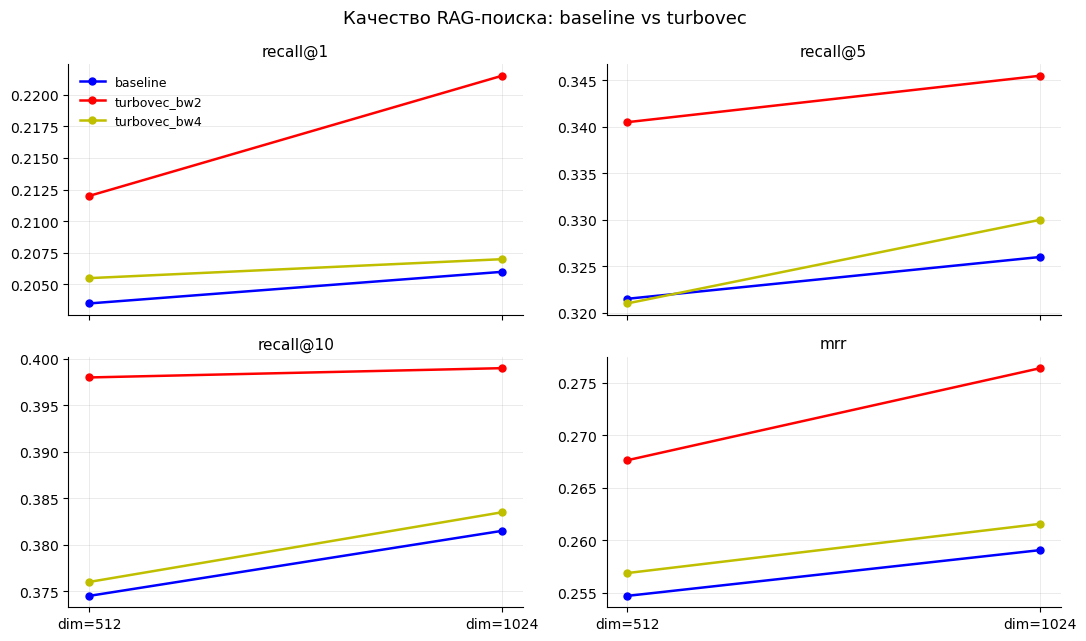

In [23]:
COLORS = {"baseline": "b", "turbovec_bw2": "r", "turbovec_bw4": "y"}

plot_df = metrics_df.sort_values("dim").copy()
plot_df["config"] = "dim=" + plot_df["dim"].astype(str)
order = plot_df["config"].drop_duplicates().tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, metric in zip(axes.ravel(), MAIN_METRICS):
    for variant, color in COLORS.items():
        sub = plot_df[plot_df["variant"] == variant].set_index("config").reindex(order)
        ax.plot(order, sub[metric], marker="o", ms=5, lw=1.8, color=color, label=variant)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Качество RAG-поиска: baseline vs turbovec", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Бутстрап доверительных интервалов

In [24]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_metric_diff_bootstrap(df, run_id, bit_width, metric='recall@10', alpha=0.05, B=1000, random_state=42):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['question_id', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['question_id', metric]]
    paired = baseline.merge(tv, on='question_id', suffixes=('_baseline', '_turbovec'))

    s_baseline = paired[metric + '_baseline'].values
    s_turbovec = paired[metric + '_turbovec'].values

    def theta_func(idx):
        idx = np.asarray(idx)
        return s_turbovec[idx].mean() - s_baseline[idx].mean()

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    p_emp = min(2 * min((theta_star > 0).mean(), (theta_star < 0).mean()), 1.0)

    return dict(run_id=run_id, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [25]:
boot_df = pd.DataFrame([
    compute_metric_diff_bootstrap(all_df, run_id, bw, metric=metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in MAIN_METRICS
])
boot_df["dim"] = boot_df["run_id"].map(lambda r: summaries[r]["dim"])
boot_df.round(5)

,run_id,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical,dim
0,20260701_190915,2,recall@1,2000,1000,0.00850,-0.00050,0.01850,0.086,512
1,20260701_190915,2,recall@5,2000,1000,0.01900,0.00950,0.02800,0.000,512
2,20260701_190915,2,recall@10,2000,1000,0.02350,0.01350,0.03350,0.000,512
3,20260701_190915,2,mrr,2000,1000,0.01293,0.00684,0.01953,0.000,512
4,20260701_190915,4,recall@1,2000,1000,0.00200,-0.00300,0.00700,0.426,512
5,20260701_190915,4,recall@5,2000,1000,-0.00050,-0.00550,0.00400,0.740,512
6,20260701_190915,4,recall@10,2000,1000,0.00150,-0.00350,0.00700,0.544,512
7,20260701_190915,4,mrr,2000,1000,0.00218,-0.00090,0.00531,0.156,512
8,20260701_231302,2,recall@1,2000,1000,0.01550,0.00600,0.02550,0.000,1024
9,20260701_231302,2,recall@5,2000,1000,0.01950,0.01100,0.02750,0.000,1024


## 5. McNemar тест

По бинарному исходу hit@k: найден ли целевой контекст в топ-k

In [26]:
def mcnemar_test(df, run_id, bit_width, metric):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['question_id', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['question_id', metric]]
    paired = baseline.merge(tv, on='question_id', suffixes=('_baseline', '_turbovec'))

    bl_ok = paired[metric + '_baseline'] > 0
    tv_ok = paired[metric + '_turbovec'] > 0
    table = [[int((bl_ok & tv_ok).sum()), int((bl_ok & ~tv_ok).sum())],
             [int((~bl_ok & tv_ok).sum()), int((~bl_ok & ~tv_ok).sum())]]

    res = mcnemar(table, exact=False, correction=True)
    return dict(run_id=run_id, bit_width=bit_width, metric=metric,
                baseline_only_hit=table[0][1], turbovec_only_hit=table[1][0],
                statistic=res.statistic, p_value=res.pvalue)

mcnemar_df = pd.DataFrame([
    mcnemar_test(all_df, run_id, bw, metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in ("recall@1", "recall@5", "recall@10")
])
mcnemar_df["dim"] = mcnemar_df["run_id"].map(lambda r: summaries[r]["dim"])
mcnemar_df.round(4)

,run_id,bit_width,metric,baseline_only_hit,turbovec_only_hit,statistic,p_value,dim
0,20260701_190915,2,recall@1,37,54,2.8132,0.0935,512
1,20260701_190915,2,recall@5,25,63,15.5568,0.0001,512
2,20260701_190915,2,recall@10,26,73,21.3737,0.0000,512
3,20260701_190915,4,recall@1,12,16,0.3214,0.5708,512
4,20260701_190915,4,recall@5,12,11,0.0000,1.0000,512
5,20260701_190915,4,recall@10,13,16,0.1379,0.7103,512
6,20260701_231302,2,recall@1,32,63,9.4737,0.0021,1024
7,20260701_231302,2,recall@5,15,54,20.9275,0.0000,1024
8,20260701_231302,2,recall@10,23,58,14.2716,0.0002,1024
9,20260701_231302,4,recall@1,9,11,0.0500,0.8231,1024


## 6. Forest plot

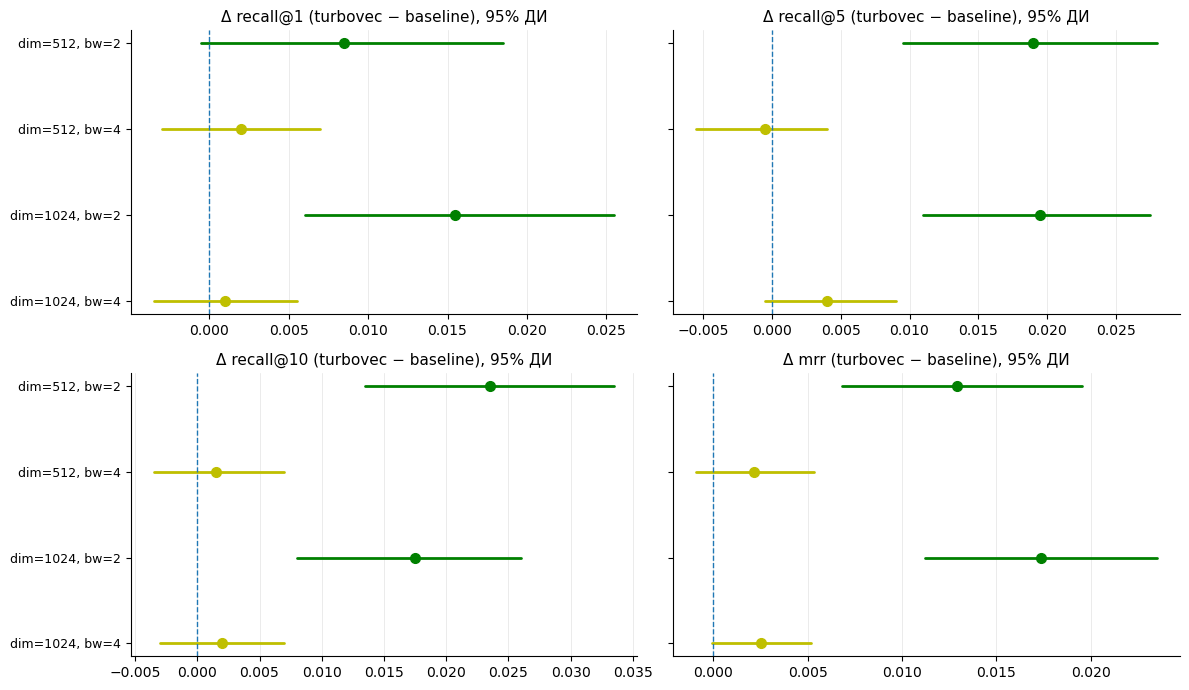

In [27]:
BW_COLORS = {2: "g", 4: "y"}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, metric in zip(axes.ravel(), MAIN_METRICS):
    sub = boot_df[boot_df["metric"] == metric].sort_values(
        ["dim", "bit_width"]).reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        color = BW_COLORS[row["bit_width"]]
        ax.plot([row["ci95_low"], row["ci95_high"]], [ypos[i]] * 2,
                color=color, lw=2, solid_capstyle="round")
        ax.plot(row["observed_diff_turbovec_minus_baseline"], ypos[i], "o", ms=7, color=color)
    ax.axvline(0, lw=1, ls="--")
    labels = ("dim=" + sub["dim"].astype(str) + ", bw=" + sub["bit_width"].astype(str))
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"Δ {metric} (turbovec − baseline), 95% ДИ", fontsize=11)
    ax.grid(axis="x", alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## Вывод

Тurbovec не ухудшает качество RAG-поиска:

- Ни одной значимой просадки: 0 из 16 сравнений (bootstrap), McNemar: 0 из 12
- bw=2 статистически значимо лучше baseline в обоих прогонах: recall@5 +1.9 п.п., recall@10 +2.1…+2.4 п.п., MRR +0.013…+0.017 (95% CI выше нуля).
- bw=4 неотличим от baseline по всем метрикам в обоих прогонах (dim=512, dim=1024).